In [18]:
# CELLULE 1 - Imports et chargement des données preprocessées
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, recall_score,
                             precision_score, accuracy_score,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import warnings
warnings.filterwarnings('ignore')

COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

print(f"X_train : {X_train.shape} | X_test : {X_test.shape}")
print(f"Proportion pannes train : {y_train.mean():.1%}")

X_train : (19233, 14) | X_test : (4809, 14)
Proportion pannes train : 14.8%


In [19]:
# CELLULE 2 - Fonction d'évaluation commune
def evaluate_model(name, model, X_test, y_test, results={}):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba)
    }
    
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, 
          target_names=['Pas de panne', 'Panne']))
    print(f"ROC-AUC : {results[name]['ROC-AUC']:.4f}")
    
    return results

results = {}
print("Fonction d'évaluation prête")

Fonction d'évaluation prête


In [20]:
# CELLULE 3 - Modele 1 : Logistic Regression (baseline)
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

results = evaluate_model('Logistic Regression', lr, X_test, y_test, results)

joblib.dump(lr, '../models/logistic_regression.joblib')


  Logistic Regression
              precision    recall  f1-score   support

Pas de panne       0.98      0.91      0.95      4097
       Panne       0.64      0.89      0.75       712

    accuracy                           0.91      4809
   macro avg       0.81      0.90      0.85      4809
weighted avg       0.93      0.91      0.92      4809

ROC-AUC : 0.9588


['../models/logistic_regression.joblib']

In [21]:
# CELLULE 4 - Modele 2 : Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                             class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)

results = evaluate_model('Random Forest', rf, X_test, y_test, results)

joblib.dump(rf, '../models/random_forest.joblib')


  Random Forest
              precision    recall  f1-score   support

Pas de panne       0.98      0.98      0.98      4097
       Panne       0.90      0.88      0.89       712

    accuracy                           0.97      4809
   macro avg       0.94      0.93      0.94      4809
weighted avg       0.97      0.97      0.97      4809

ROC-AUC : 0.9938


['../models/random_forest.joblib']

In [23]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

0

In [24]:
# CELLULE 5 - Modele 3 : Gradient Boosting (XGBoost)
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=100, random_state=42,
                    scale_pos_weight=scale_pos_weight,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)

results = evaluate_model('XGBoost', xgb, X_test, y_test, results)

joblib.dump(xgb, '../models/xgboost.joblib')


  XGBoost
              precision    recall  f1-score   support

Pas de panne       0.99      0.98      0.98      4097
       Panne       0.88      0.96      0.92       712

    accuracy                           0.97      4809
   macro avg       0.94      0.97      0.95      4809
weighted avg       0.98      0.97      0.97      4809

ROC-AUC : 0.9955


['../models/xgboost.joblib']

In [25]:
import subprocess
import sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tensorflow'])

0

In [27]:
# CELLULE 6 - Modele 4 : MLP (Deep Learning)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_mlp.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Poids des classes pour gérer le déséquilibre
class_weight = {0: 1.0, 1: (y_train == 0).sum() / (y_train == 1).sum()}

history = model_mlp.fit(X_train, y_train,
                        epochs=100,
                        batch_size=256,
                        validation_split=0.2,
                        class_weight=class_weight,
                        callbacks=[early_stop],
                        verbose=1)

Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7254 - loss: 0.8293 - val_accuracy: 0.9127 - val_loss: 0.4957
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8814 - loss: 0.5304 - val_accuracy: 0.9257 - val_loss: 0.3364
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8989 - loss: 0.4613 - val_accuracy: 0.9259 - val_loss: 0.2682
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9017 - loss: 0.4210 - val_accuracy: 0.9337 - val_loss: 0.2102
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9092 - loss: 0.3994 - val_accuracy: 0.9233 - val_loss: 0.2115
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9125 - loss: 0.3792 - val_accuracy: 0.9322 - val_loss: 0.1800
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9147 - loss: 0.3655 - val_accuracy: 0.9322 - val_loss: 0.1674
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9163 - loss: 0.3475 - val_accuracy: 0.9262 - v

In [28]:
print("MLP termine !")
print(f"Nombre d'epochs effectues : {len(history.history['loss'])}")

MLP termine !
Nombre d'epochs effectues : 17


In [29]:
# CELLULE 7 - Evaluation MLP
from sklearn.metrics import classification_report, roc_auc_score

y_proba_mlp = model_mlp.predict(X_test, verbose=0).flatten()
y_pred_mlp = (y_proba_mlp >= 0.5).astype(int)

results['MLP'] = {
    'Accuracy':  accuracy_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Recall':    recall_score(y_test, y_pred_mlp),
    'F1':        f1_score(y_test, y_pred_mlp),
    'ROC-AUC':   roc_auc_score(y_test, y_proba_mlp)
}

print("MLP (Deep Learning)")
print("="*50)
print(classification_report(y_test, y_pred_mlp,
      target_names=['Pas de panne', 'Panne']))
print(f"ROC-AUC : {results['MLP']['ROC-AUC']:.4f}")

model_mlp.save('../models/mlp_model.keras')
print("Modele sauvegarde")

MLP (Deep Learning)
              precision    recall  f1-score   support

Pas de panne       0.98      0.94      0.96      4097
       Panne       0.71      0.90      0.79       712

    accuracy                           0.93      4809
   macro avg       0.85      0.92      0.88      4809
weighted avg       0.94      0.93      0.93      4809

ROC-AUC : 0.9743
Modele sauvegarde


COMPARAISON DES 4 MODELES
                     Accuracy  Precision  Recall      F1  ROC-AUC
XGBoost                0.9744     0.8820  0.9551  0.9171   0.9955
Random Forest          0.9682     0.9010  0.8820  0.8914   0.9938
MLP                    0.9310     0.7111  0.8989  0.7940   0.9743
Logistic Regression    0.9102     0.6408  0.8947  0.7468   0.9588


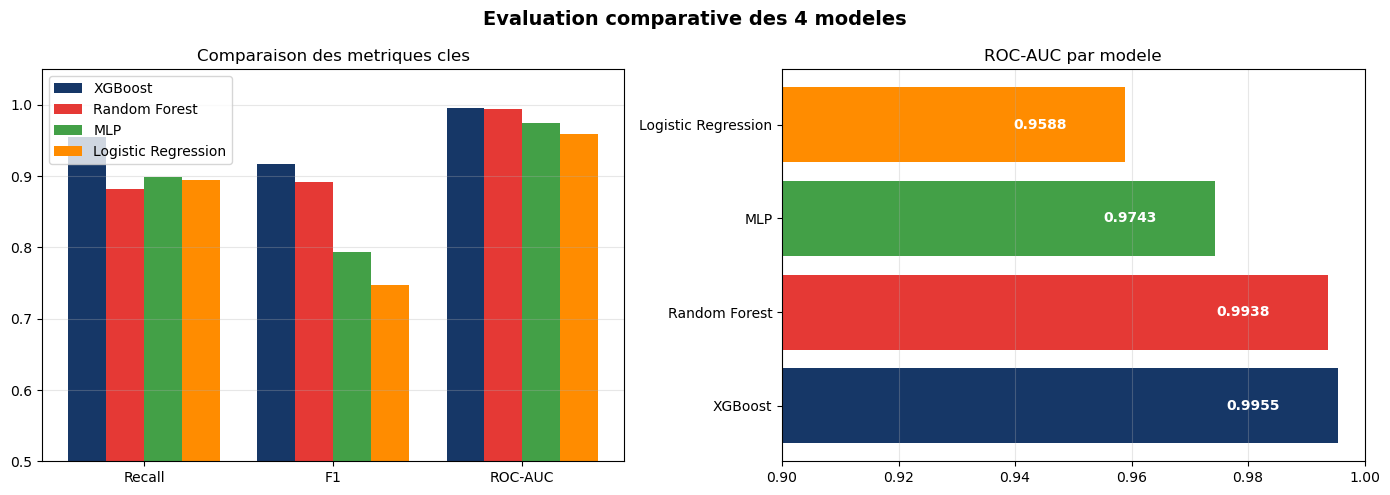

In [30]:
# CELLULE 8 - Tableau comparatif des 4 modeles
df_results = pd.DataFrame(results).T.round(4)
df_results = df_results.sort_values('ROC-AUC', ascending=False)

print("COMPARAISON DES 4 MODELES")
print("="*60)
print(df_results.to_string())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.2
colors = [COLOR_BLUE, COLOR_RED, COLOR_GREEN, '#FF8C00']
models = list(df_results.index)

for i, (model, color) in enumerate(zip(models, colors)):
    vals = [df_results.loc[model, m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=model, color=color)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Comparaison des metriques cles')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC seul
roc_vals = [df_results.loc[m, 'ROC-AUC'] for m in models]
bars = axes[1].barh(models, roc_vals, color=colors)
for bar, val in zip(bars, roc_vals):
    axes[1].text(bar.get_width() - 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', ha='right', 
                 color='white', fontweight='bold')
axes[1].set_xlim(0.9, 1.0)
axes[1].set_title('ROC-AUC par modele')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Evaluation comparative des 4 modeles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()